# Example: Finite Volume Method Applied to a Lid-Driven Cavity

To discretize these continuous surface and volume integrals over a 2D grid, we partition the domain into rectangular control volumes $CV_{i,j}$ of cell area $V_{i,j} = \iint_{CV_{i,j}} dA = \Delta x \Delta y$, where the bounding surface $CS$ decomposes into four straight faces: $CS = S_e \cup S_w \cup S_n \cup S_s$.

We can perform surface integral decomposition across control volume boundaries. Evaluating the outward unit normal vectors $\mathbf{n} = (n_x, n_y)^T$ for each face:

* **East face ($S_e$)**: $\mathbf{n}_e = (1, 0)^T$, differential element $dS = dy$, face area $A_e = \Delta y$
* **West face ($S_w$)**: $\mathbf{n}_w = (-1, 0)^T$, differential element $dS = dy$, face area $A_w = \Delta y$
* **North face ($S_n$)**: $\mathbf{n}_n = (0, 1)^T$, differential element $dS = dx$, face area $A_n = \Delta x$
* **South face ($S_s$)**: $\mathbf{n}_s = (0, -1)^T$, differential element $dS = dx$, face area $A_s = \Delta x$

Expanding your continuous $x$-momentum surface integral $\iint_{CS} [\dots] dS$ across these four individual boundaries gives:

$$\iint_{CS} [\dots] dS = \int_{S_e} \left[ \rho u u - \left(-p + 2\mu \frac{\partial u}{\partial x}\right) \right] dy - \int_{S_w} \left[ \rho u u - \left(-p + 2\mu \frac{\partial u}{\partial x}\right) \right] dy + \int_{S_n} \left[ \rho u v - \mu \left( \frac{\partial u}{\partial y} + \frac{\partial v}{\partial x} \right) \right] dx - \int_{S_s} \left[ \rho u v - \mu \left( \frac{\partial u}{\partial y} + \frac{\partial v}{\partial x} \right) \right] dx$$

### `compute_face_fluxes`

Applying the midpoint rule over each face, the continuous flux integrands split into convective flux densities $F_c$ and diffusive flux densities $F_d$, leaving pressure to be treated during the projection step:

| Face ($f$) | Convective Flux Density $F_{c,u}$ | Diffusive Flux Density $F_{d,u}$ | Code Variable |
| --- | --- | --- | --- |
| **East ($e$)** | $F_{c,u,e} = \rho u_e u_e$ | $F_{d,u,e} = \mu \frac{u_{i+1,j} - u_{i,j}}{\Delta x}$ | `Fc_u_e`, `Fd_u_e` |
| **West ($w$)** | $F_{c,u,w} = \rho u_w u_w$ | $F_{d,u,w} = \mu \frac{u_{i,j} - u_{i-1,j}}{\Delta x}$ | `Fc_u_w`, `Fd_u_w` |
| **North ($n$)** | $F_{c,u,n} = \rho v_n u_n$ | $F_{d,u,n} = \mu \frac{u_{i,j+1} - u_{i,j}}{\Delta y}$ | `Fc_u_n`, `Fd_u_n` |
| **South ($s$)** | $F_{c,u,s} = \rho v_s u_s$ | $F_{d,u,s} = \mu \frac{u_{i,j} - u_{i,j-1}}{\Delta y}$ | `Fc_u_s`, `Fd_u_s` |

*(Note: Cross-derivative terms like $\frac{\partial v}{\partial x}$ evaluate to zero across face integrals on structured orthogonal grids for incompressible flow).*

### `assemble_volume_balances`

Approximating cell-centered values as volume averages ($\iint_{CV_{i,j}} u \, dA \approx u_{i,j} \Delta x \Delta y$), the continuous accumulation term discretizes via forward Euler:

$$\rho \frac{\partial}{\partial t} \iint_{CV_{i,j}} u \, dA \approx \rho \Delta x \Delta y \frac{u_{i,j}^* - u_{i,j}^n}{\Delta t}$$

Multiplying the flux densities by face areas ($A_e=A_w=\Delta y$, $A_n=A_s=\Delta x$) forms the net surface force `net_force_u`:

$$\text{net\_force\_u} = (F_{c,u,e} - F_{d,u,e}) A_e - (F_{c,u,w} - F_{d,u,w}) A_w + (F_{c,u,n} - F_{d,u,n}) A_n - (F_{c,u,s} - F_{d,u,s}) A_s$$

Setting $\rho V_{ij} \frac{u_{i,j}^* - u_{i,j}^n}{\Delta t} + \text{net\_force\_u} = 0$ directly yields the code update:

$$u_{i,j}^* = u_{i,j}^n - \frac{\Delta t}{\rho V_{ij}} \text{net\_force\_u}$$

### `solve_pressure_poisson`

Integrating the pressure term $-\iint_{CS} p n_x dS$ over cell boundaries provides the discrete pressure force applied in the velocity correction step:

$$-\iint_{CS} p n_x \, dS \approx - (p_e - p_w) A_e \implies u_{i,j}^{n+1} = u_{i,j}^* - \frac{\Delta t}{\rho V_{ij}} (p_{e,ij} - p_{w,ij}) A_e$$

Running FVM Solver: Re=200.0, Grid=202x202, dt=0.0006126850308793255s
Step 0200 | Max U: 1.9095 m/s | Min U: -0.3486 m/s
Step 0400 | Max U: 1.9335 m/s | Min U: -0.3905 m/s
Step 0600 | Max U: 1.9449 m/s | Min U: -0.4234 m/s
Step 0800 | Max U: 1.9513 m/s | Min U: -0.4502 m/s
Step 1000 | Max U: 1.9552 m/s | Min U: -0.4721 m/s
Step 1200 | Max U: 1.9578 m/s | Min U: -0.4890 m/s
Step 1400 | Max U: 1.9595 m/s | Min U: -0.5022 m/s
Step 1600 | Max U: 1.9606 m/s | Min U: -0.5121 m/s
Step 1800 | Max U: 1.9613 m/s | Min U: -0.5196 m/s
Step 2000 | Max U: 1.9618 m/s | Min U: -0.5256 m/s
Step 2200 | Max U: 1.9621 m/s | Min U: -0.5304 m/s
Step 2400 | Max U: 1.9623 m/s | Min U: -0.5345 m/s
Step 2600 | Max U: 1.9624 m/s | Min U: -0.5378 m/s
Step 2800 | Max U: 1.9625 m/s | Min U: -0.5409 m/s
Step 3000 | Max U: 1.9626 m/s | Min U: -0.5435 m/s
Step 3200 | Max U: 1.9627 m/s | Min U: -0.5460 m/s
Step 3400 | Max U: 1.9628 m/s | Min U: -0.5483 m/s
Step 3600 | Max U: 1.9628 m/s | Min U: -0.5503 m/s
Step 3800 | 

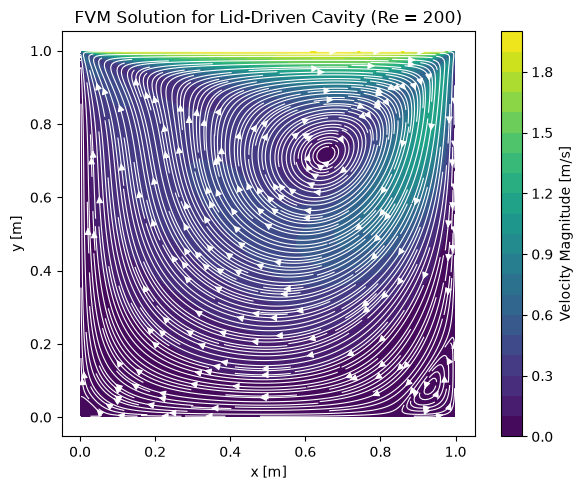

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def compute_face_fluxes(u, v, rho, mu, dx, dy, u_lid=1.0):
    """
    Computes convective and diffusive momentum flux densities [N/m^2] at all cell faces.
    
    Parameters:
        u, v   : Velocity arrays at cell centers [m/s]
        rho    : Fluid density [kg/m^3]
        mu     : Dynamic viscosity [Pa s = kg/(m s)]
        dx, dy : Spatial cell dimensions [m]
        u_lid  : Lid velocity [m/s]
        
    Returns:
        fluxes : Dictionary containing explicit face flux density arrays [N/m^2]
    """
    Ny, Nx = u.shape
    
    # Pre-allocate flux density arrays for u and v momentum
    # Vertical (East/West) faces: shape (Ny, Nx+1)
    F_conv_u_e = np.zeros((Ny, Nx + 1))
    F_diff_u_e = np.zeros((Ny, Nx + 1))
    F_conv_v_e = np.zeros((Ny, Nx + 1))
    F_diff_v_e = np.zeros((Ny, Nx + 1))
    
    # Horizontal (North/South) faces: shape (Ny+1, Nx)
    F_conv_u_n = np.zeros((Ny + 1, Nx))
    F_diff_u_n = np.zeros((Ny + 1, Nx))
    F_conv_v_n = np.zeros((Ny + 1, Nx))
    F_diff_v_n = np.zeros((Ny + 1, Nx))

    # --- INTERIOR VERTICAL FACES (East) ---
    u_e = 0.5 * (u[:, :-1] + u[:, 1:])  # Face velocity [m/s]
    v_e = 0.5 * (v[:, :-1] + v[:, 1:])  # Face velocity [m/s]
    
    F_conv_u_e[:, 1:-1] = rho * u_e * u_e
    F_diff_u_e[:, 1:-1] = mu * (u[:, 1:] - u[:, :-1]) / dx
    
    F_conv_v_e[:, 1:-1] = rho * u_e * v_e
    F_diff_v_e[:, 1:-1] = mu * (v[:, 1:] - v[:, :-1]) / dx

    # --- BOUNDARY VERTICAL FACES (West & East Walls) ---
    # West Wall (i = 0 face, no-slip u=0, v=0)
    F_conv_u_e[:, 0] = 0.0
    F_diff_u_e[:, 0] = mu * (u[:, 0] - 0.0) / (0.5 * dx)
    F_conv_v_e[:, 0] = 0.0
    F_diff_v_e[:, 0] = mu * (v[:, 0] - 0.0) / (0.5 * dx)
    
    # East Wall (i = Nx face, no-slip u=0, v=0)
    F_conv_u_e[:, -1] = 0.0
    F_diff_u_e[:, -1] = mu * (0.0 - u[:, -1]) / (0.5 * dx)
    F_conv_v_e[:, -1] = 0.0
    F_diff_v_e[:, -1] = mu * (0.0 - v[:, -1]) / (0.5 * dx)

    # --- INTERIOR HORIZONTAL FACES (North) ---
    u_n = 0.5 * (u[:-1, :] + u[1:, :])  # Face velocity [m/s]
    v_n = 0.5 * (v[:-1, :] + v[1:, :])  # Face velocity [m/s]
    
    F_conv_u_n[1:-1, :] = rho * v_n * u_n
    F_diff_u_n[1:-1, :] = mu * (u[1:, :] - u[:-1, :]) / dy
    
    F_conv_v_n[1:-1, :] = rho * v_n * v_n
    F_diff_v_n[1:-1, :] = mu * (v[1:, :] - v[:-1, :]) / dy

    # --- BOUNDARY HORIZONTAL FACES (South & North Walls) ---
    # South Wall (j = 0 face, no-slip u=0, v=0)
    F_conv_u_n[0, :] = 0.0
    F_diff_u_n[0, :] = mu * (u[0, :] - 0.0) / (0.5 * dy)
    F_conv_v_n[0, :] = 0.0
    F_diff_v_n[0, :] = mu * (v[0, :] - 0.0) / (0.5 * dy)
    
    # North Lid Wall (j = Ny face, lid velocity u=u_lid, v=0)
    F_conv_u_n[-1, :] = 0.0  # Mass flux through impenetrable top boundary is zero (v=0)
    F_diff_u_n[-1, :] = mu * (u_lid - u[-1, :]) / (0.5 * dy)
    F_conv_v_n[-1, :] = 0.0
    F_diff_v_n[-1, :] = mu * (0.0 - v[-1, :]) / (0.5 * dy)

    return {
        'Fc_u_e': F_conv_u_e, 'Fd_u_e': F_diff_u_e,
        'Fc_u_n': F_conv_u_n, 'Fd_u_n': F_diff_u_n,
        'Fc_v_e': F_conv_v_e, 'Fd_v_e': F_diff_v_e,
        'Fc_v_n': F_conv_v_n, 'Fd_v_n': F_diff_v_n
    }


def assemble_volume_balances(u, v, fluxes, rho, dt, dx, dy):
    """
    Assembles explicit volume integral balances to evaluate intermediate field (u*, v*).
    
    Integrates surface flux forces [N] over cell volumes V_ij [m^2] without dividing out dx or dy.
    """
    # Explicit measures
    V_ij = dx * dy  # Cell volume [m^2]
    A_e, A_w = dy, dy  # Face areas [m]
    A_n, A_s = dx, dx  # Face areas [m]
    
    # Extract east, west, north, and south face flux densities
    Fc_u_e, Fd_u_e = fluxes['Fc_u_e'][:, 1:], fluxes['Fd_u_e'][:, 1:]
    Fc_u_w, Fd_u_w = fluxes['Fc_u_e'][:, :-1], fluxes['Fd_u_e'][:, :-1]
    Fc_u_n, Fd_u_n = fluxes['Fc_u_n'][1:, :], fluxes['Fd_u_n'][1:, :]
    Fc_u_s, Fd_u_s = fluxes['Fc_u_n'][:-1, :], fluxes['Fd_u_n'][:-1, :]

    Fc_v_e, Fd_v_e = fluxes['Fc_v_e'][:, 1:], fluxes['Fd_v_e'][:, 1:]
    Fc_v_w, Fd_v_w = fluxes['Fc_v_e'][:, :-1], fluxes['Fd_v_e'][:, :-1]
    Fc_v_n, Fd_v_n = fluxes['Fc_v_n'][1:, :], fluxes['Fd_v_n'][1:, :]
    Fc_v_s, Fd_v_s = fluxes['Fc_v_n'][:-1, :], fluxes['Fd_v_n'][:-1, :]

    # Net surface forces acting on control volume V_ij [Newtons]
    net_force_u = ( (Fc_u_e - Fd_u_e) * A_e - (Fc_u_w - Fd_u_w) * A_w +
                    (Fc_u_n - Fd_u_n) * A_n - (Fc_u_s - Fd_u_s) * A_s )
                    
    net_force_v = ( (Fc_v_e - Fd_v_e) * A_e - (Fc_v_w - Fd_v_w) * A_w +
                    (Fc_v_n - Fd_v_n) * A_n - (Fc_v_s - Fd_v_s) * A_s )

    # Time integration: V_ij * rho * (phi* - phi^n) / dt + net_force = 0
    u_star = u - (dt / (rho * V_ij)) * net_force_u
    v_star = v - (dt / (rho * V_ij)) * net_force_v

    return u_star, v_star


def solve_pressure_poisson(p, u_star, v_star, rho, dt, dx, dy, max_iter=1000, tol=1e-5):
    """
    Enforces face-based mass conservation via Rhie-Chow momentum interpolation 
    and solves the Pressure Poisson Equation.
    """
    Ny, Nx = p.shape
    V_ij = dx * dy
    A_e, A_w = dy, dy
    A_n, A_s = dx, dx
    
    # 1. Rhie-Chow Interpolation for cell-face intermediate velocities [m/s]
    u_e_star = np.zeros((Ny, Nx + 1))
    v_n_star = np.zeros((Ny + 1, Nx))
    
    u_e_star[:, 1:-1] = 0.5 * (u_star[:, :-1] + u_star[:, 1:])
    v_n_star[1:-1, :] = 0.5 * (v_star[:-1, :] + v_star[1:, :])

    # 2. Cell mass defect divergence term [kg/s]
    # Source = sum(rho * u_face * A_face)
    mass_source = rho * (
        u_e_star[:, 1:] * A_e - u_e_star[:, :-1] * A_w +
        v_n_star[1:, :] * A_n - v_n_star[:-1, :] * A_s
    )

    # 3. Solve Discrete Pressure Poisson Equation
    p_new = p.copy()
    
    # Face transmissibility coefficients [m s]
    coeff_E = np.ones((Ny, Nx)) * (dt / dx) * A_e
    coeff_W = np.ones((Ny, Nx)) * (dt / dx) * A_w
    coeff_N = np.ones((Ny, Nx)) * (dt / dy) * A_n
    coeff_S = np.ones((Ny, Nx)) * (dt / dy) * A_s

    # Zero-gradient (Neumann) BCs on pressure at domain faces
    coeff_E[:, -1] = 0.0
    coeff_W[:, 0] = 0.0
    coeff_N[-1, :] = 0.0
    coeff_S[0, :] = 0.0

    coeff_P = coeff_E + coeff_W + coeff_N + coeff_S

    for _ in range(max_iter):
        p_old = p_new.copy()
        
        p_E = np.roll(p_old, -1, axis=1); p_E[:, -1] = p_old[:, -1]
        p_W = np.roll(p_old, 1, axis=1);  p_W[:, 0]  = p_old[:, 0]
        p_N = np.roll(p_old, -1, axis=0); p_N[-1, :] = p_old[-1, :]
        p_S = np.roll(p_old, 1, axis=0);  p_S[0, :]  = p_old[0, :]

        p_new = (coeff_E * p_E + coeff_W * p_W + coeff_N * p_N + coeff_S * p_S - mass_source) / coeff_P
        p_new -= p_new[0, 0]  # Reference pressure gauge pinning

        if np.linalg.norm(p_new - p_old, ord=np.inf) < tol:
            break

    # 4. Correct Cell-Centered Velocity using integrated face pressure forces
    p_E_cell = np.zeros((Ny, Nx))
    p_W_cell = np.zeros((Ny, Nx))
    p_N_cell = np.zeros((Ny, Nx))
    p_S_cell = np.zeros((Ny, Nx))

    p_E_cell[:, :-1] = 0.5 * (p_new[:, :-1] + p_new[:, 1:])
    p_E_cell[:, -1] = p_new[:, -1]
    p_W_cell[:, 1:] = 0.5 * (p_new[:, :-1] + p_new[:, 1:])
    p_W_cell[:, 0] = p_new[:, 0]

    p_N_cell[:-1, :] = 0.5 * (p_new[:-1, :] + p_new[1:, :])
    p_N_cell[-1, :] = p_new[-1, :]
    p_S_cell[1:, :] = 0.5 * (p_new[:-1, :] + p_new[1:, :])
    p_S_cell[0, :] = p_new[0, :]

    u_next = u_star - (dt / (rho * V_ij)) * (p_E_cell - p_W_cell) * A_e
    v_next = v_star - (dt / (rho * V_ij)) * (p_N_cell - p_S_cell) * A_n

    return p_new, u_next, v_next


# --- DRIVER SIMULATION SCRIPT ---
if __name__ == "__main__":
    # Physical Domain Parameters
    Lx, Ly = 1.0, 1.0       # Domain size [m]
    #Nx, Ny = 32, 32         # Grid resolution
    Nx, Ny = 202, 202         # Grid resolution
    dx, dy = Lx / Nx, Ly / Ny
    
    # Fluid Properties
    rho = 1.0               # Density [kg/m^3]
    Re = 200.0              # Reynolds number
    u_lid = 2.0             # Lid velocity [m/s]
    mu = rho * u_lid * Lx / Re  # Dynamic viscosity [Pa s]
    nu = mu/rho
    
    # dt = 0.0005             # Time step [s] 
    dt = 1.0 / (2.0 * nu * (1.0 / dx**2 + 1.0 / dy**2))
    # n_steps = 1000
    n_steps = 4000

    # Field Initializations
    u = np.zeros((Ny, Nx))
    v = np.zeros((Ny, Nx))
    p = np.zeros((Ny, Nx))

    print(f"Running FVM Solver: Re={Re}, Grid={Nx}x{Ny}, dt={dt}s")

    for step in range(1, n_steps + 1):
        fluxes = compute_face_fluxes(u, v, rho, mu, dx, dy, u_lid=u_lid)
        u_star, v_star = assemble_volume_balances(u, v, fluxes, rho, dt, dx, dy)
        p, u, v = solve_pressure_poisson(p, u_star, v_star, rho, dt, dx, dy)

        if step % 200 == 0:
            print(f"Step {step:04d} | Max U: {np.max(u):.4f} m/s | Min U: {np.min(u):.4f} m/s")

    # Plot velocity magnitude and streamlines
    X, Y = np.meshgrid(np.linspace(dx/2, Lx-dx/2, Nx), np.linspace(dy/2, Ly-dy/2, Ny))
    plt.figure(figsize=(6, 5))
    plt.contourf(X, Y, np.sqrt(u**2 + v**2), levels=20, cmap='viridis')
    plt.colorbar(label='Velocity Magnitude [m/s]')
    plt.streamplot(X, Y, u, v, color='white', linewidth=0.8, density=4)
    # plt.title('Explicit FVM Lid-Driven Cavity Flow')
    plt.title(f"FVM Solution for Lid-Driven Cavity (Re = {int(Re)})")
    plt.xlabel('x [m]')
    plt.ylabel('y [m]')
    plt.tight_layout()
    plt.savefig("2D-lid-driven-cavity-finite-volume_Re_200.pdf")
    plt.show()

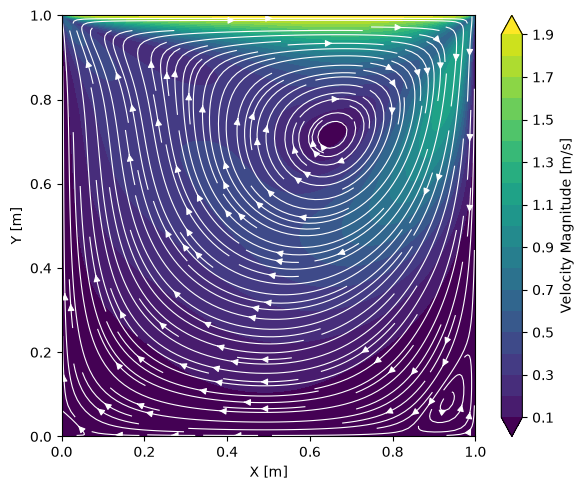

In [12]:
X, Y = np.meshgrid(np.linspace(dx/2, Lx-dx/2, Nx), np.linspace(dy/2, Ly-dy/2, Ny))
# levels = np.linspace(0, 2, 31)

plt.figure(figsize=(6, 5))
plt.contourf(X, Y, np.sqrt(u**2 + v**2), levels=20, cmap='viridis', vmin=0, vmax=2, extend='both')
plt.colorbar(label='Velocity Magnitude [m/s]')
plt.streamplot(X, Y, u, v, color='white', linewidth=0.8, density=2)
# plt.title('Explicit FVM Lid-Driven Cavity Flow')
# plt.title(f"FVM Solution for Lid-Driven Cavity (Re = {int(Re)})")
plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("2D-lid-driven-cavity-finite-volume_Re_200.pdf")
plt.show()